# Task 1: Dataset Preparation
In this task, text is collected from IIT Jodhpur web pages and PDF documents, then cleaned into a usable corpus. The goal is to produce a high-quality domain corpus with clear statistics (documents, tokens, vocabulary) and a word cloud for exploratory analysis.

In [ ]:
# Imports for web collection, NLP preprocessing, and plotting workflow.
import requests  # HTTP requests for webpage scraping
from bs4 import BeautifulSoup  # HTML parser for extracting visible text
import re  # Regex-based cleaning utilities
import nltk  # Tokenization and linguistic preprocessing
from collections import Counter  # Frequency counting for vocabulary stats
from wordcloud import WordCloud  # Word cloud visualization
import matplotlib.pyplot as plt  # Plotting utilities
from gensim.models import Word2Vec  # Baseline Word2Vec reference import
import numpy as np  # Numeric array operations
from sklearn.manifold import TSNE  # 2D projection for embedding visualization
import warnings  # Suppress noisy notebook warnings

# Disable warning spam so training/stat outputs remain readable.
warnings.filterwarnings('ignore')  # Keep output readable

# NLTK data downloads are required only once per environment.
# Keeping them in notebook ensures portability on fresh systems.
nltk.download('punkt')  # Tokenizer model
nltk.download('stopwords')  # English stopword list
nltk.download('punkt_tab')  # Punkt tables used by tokenizer
from nltk.corpus import stopwords
nltk.download('wordnet')  # WordNet data for lemmatization
nltk.download('omw-1.4')  # Multilingual WordNet data dependency
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\japne\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\japne\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Zip Slip blocked: stopwords/
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\japne\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\japne\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\japne\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [ ]:
# Additional imports kept local to this scraping cell for standalone execution.
import requests
from bs4 import BeautifulSoup
import nltk
import os
import PyPDF2

# Primary URL list used in early scraping trials / curated sources.
iitj_urls = [
    # Academic Regulations & Programs
    "https://iitj.ac.in/office-of-academics/en/academic-regulations",
    "https://www.iitj.ac.in/Bachelor-of-Technology/en/Bachelor-of-Technology",
    "https://iitj.ac.in/office-of-academics/en/list-of-academic-programs",
    "https://iitj.ac.in/office-of-academics/en/academics",
    "https://iitj.ac.in/office-of-academics/en/academic-programs",
    "https://iitj.ac.in/office-of-academics/en/program-Structure",
    "https://www.iitj.ac.in/admission-postgraduate-programs/en/Admission-to-Postgraduate-Programs",
    "https://www.iitj.ac.in/school-of-liberal-arts/en/doctoral-program",

    # Department Specific
    "https://www.iitj.ac.in/computer-science-engineering/en/undergraduate-programs",
    "https://iitj.ac.in/computer-science-engineering/en/postgraduate-programs",
    "https://iitj.ac.in/computer-science-engineering/en/doctoral-programs",
    "https://www.iitj.ac.in/computer-science-engineering",
    "https://www.iitj.ac.in/electrical-engineering",
    "https://www.iitj.ac.in/mechanical-engineering",
    "https://www.iitj.ac.in/mathematics",
    "https://www.iitj.ac.in/physics",
    "https://www.iitj.ac.in/chemistry",
    "https://www.iitj.ac.in/bioscience-bioengineering",
    "https://www.iitj.ac.in/chemical-engineering",

    # Research and Centers
    "https://www.iitj.ac.in/office-of-research-development/en/office-of-research-and-development",
    "https://www.iitj.ac.in/rcric/en/academics",
    "https://www.iitj.ac.in/crf/en/crf",
    "https://iitj.ac.in/research/en/research-areas",
    "https://iitj.ac.in/research/en/overview",
    "https://iitj.ac.in/research/en/innovation",

    # Faculty Profiles
    "https://iitj.ac.in/main/en/faculty-members",
    "https://iitj.ac.in/computer-science-engineering/en/faculty",
    "https://iitj.ac.in/electrical-engineering/en/faculty",

    # Research Achievements
    "https://iitj.ac.in/computer-science-engineering/en/faculty-achievements",
    "https://iitj.ac.in/electrical-engineering/en/research",

    # Postgraduate Programs
    "https://iitj.ac.in/electrical-engineering/en/postgraduate-programs"
]

# Expanded URL list actually used for richer final corpus collection.
iitj_urls_2 = [
    # Academic Regulations & Programs
    "https://iitj.ac.in/office-of-academics/en/academic-regulations",
    "https://www.iitj.ac.in/Bachelor-of-Technology/en/Bachelor-of-Technology",
    "https://iitj.ac.in/office-of-academics/en/list-of-academic-programs",
    "https://iitj.ac.in/office-of-academics/en/academics",
    "https://iitj.ac.in/office-of-academics/en/academic-programs",
    "https://iitj.ac.in/office-of-academics/en/program-Structure",
    "https://www.iitj.ac.in/admission-postgraduate-programs/en/Admission-to-Postgraduate-Programs",
    "https://www.iitj.ac.in/school-of-liberal-arts/en/doctoral-program",

    # Course Syllabus & Curriculum Pages
    "https://iitj.ac.in/office-of-academics/en/curriculum",
    "https://www.iitj.ac.in/mechanical-engineering/en/curriculum",
    "https://iitj.ac.in/electrical-engineering/en/curriculum",
    "https://iitj.ac.in/schools/en/Program-Curriculum",
    "https://www.iitj.ac.in/itep/en/curriculum",

    # Department Specific
    "https://www.iitj.ac.in/computer-science-engineering/en/undergraduate-programs",
    "https://iitj.ac.in/computer-science-engineering/en/postgraduate-programs",
    "https://iitj.ac.in/computer-science-engineering/en/doctoral-programs",
    "https://www.iitj.ac.in/computer-science-engineering",
    "https://www.iitj.ac.in/electrical-engineering",
    "https://www.iitj.ac.in/mechanical-engineering",
    "https://www.iitj.ac.in/mathematics",
    "https://www.iitj.ac.in/physics",
    "https://www.iitj.ac.in/chemistry",
    "https://www.iitj.ac.in/bioscience-bioengineering",
    "https://www.iitj.ac.in/chemical-engineering",

    # Research and Centers
    "https://www.iitj.ac.in/office-of-research-development/en/office-of-research-and-development",
    "https://www.iitj.ac.in/rcric/en/academics",
    "https://www.iitj.ac.in/crf/en/crf",
    "https://iitj.ac.in/research/en/research-areas",
    "https://iitj.ac.in/research/en/overview",
    "https://iitj.ac.in/research/en/innovation",

    # Institute Newsletters & Circulars
    "https://www.iitj.ac.in/institute-repository/en/Newsletter",
    "https://www.iitj.ac.in/school-of-liberal-arts/en/newsletter",
    "https://www.iitj.ac.in/crf/en/News-Newsletter",
    "https://www.iitj.ac.in/materials-engineering/en/News-Newsletter",

    # Announcements
    "https://www.iitj.ac.in/main/en/all-announcement",
    "https://iitj.ac.in/computer-science-engineering/en/Announcements",
    "https://www.iitj.ac.in/bioscience-bioengineering/en/Announcements",

    # Faculty Profiles
    "https://iitj.ac.in/main/en/faculty-members",
    "https://iitj.ac.in/computer-science-engineering/en/faculty",
    "https://iitj.ac.in/electrical-engineering/en/faculty",
    "https://old.iitj.ac.in/department/index.php?rec=faculty_member&dept=mathematics",

    # Research Achievements
    "https://iitj.ac.in/computer-science-engineering/en/faculty-achievements"
]

# Resolve all PDF file paths once so extractor can iterate directly.
pdf_folder = "iitj_pdfs"  # Folder containing downloaded IITJ PDF files.
pdf_files = [os.path.join(pdf_folder, f) for f in os.listdir(pdf_folder) if f.endswith('.pdf')]  # Keep only PDF paths.


# Web scraper returns one merged text string per valid URL.
def scrape_web_text(urls):
    print("Starting web scraping with URLs...")
    raw_documents = []  # Stores one cleaned text blob per successfully scraped URL.
    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}  # Browser-like header reduces blocking.

    for url in urls:
        try:
            response = requests.get(url, headers=headers, timeout=15)  # Fetch page with timeout safety.
            if response.status_code == 200:
                soup = BeautifulSoup(response.text, 'html.parser')  # Parse HTML response content.

                content_tags = soup.find_all(['p', 'li', 'h1', 'h2', 'h3', 'td'])  # Keep informative textual tags.
                page_text = " ".join([tag.get_text(separator=' ', strip=True) for tag in content_tags])  # Merge extracted snippets.

                # Convert embedded line breaks to spaces so each webpage becomes one clean line in the corpus file.
                page_text = page_text.replace('\n', ' ').replace('\r', ' ')

                # Keep only substantial pages to reduce low-content noise.
                if len(page_text.split()) > 10:  # Skip near-empty pages to reduce noise.
                    raw_documents.append(page_text)
                    print(f"[SUCCESS] Scraped 1 document ({len(page_text.split())} words) from: {url}")
                else:
                    print(f"[SKIPPED] Insufficient text on: {url}")
            else:
                print(f"[FAILED] Skipped {url} - Status: {response.status_code}")
        except Exception as e:
            print(f"[ERROR] Failed to scrape {url}: {e}")

    return raw_documents

# PDF extractor returns one merged text string per PDF file.
def extract_pdf_text(pdf_list):
    print("\nStarting PDF extraction...")
    raw_documents = []  # Stores one merged text blob per PDF file.

    for pdf_file in pdf_list:
        if not os.path.exists(pdf_file):
            print(f"  [SKIPPED] File not found: {pdf_file}")
            continue

        try:
            with open(pdf_file, "rb") as file:
                reader = PyPDF2.PdfReader(file)
                page_texts = []  # Temporary page-wise storage before document merge.

                for page in reader.pages:
                    text = page.extract_text()  # Pull text from each page.
                    if not text:
                        continue
                    text = re.sub(r"(?<=\w)-\s+(?=\w)", "", text)  # Join words split across line-break hyphens.
                    text = re.sub(r"\s+", " ", text).strip()  # Normalize repeated whitespace.
                    if text:
                        page_texts.append(text)

                # Merge all page texts from one file as one document unit.
                pdf_text = " ".join(page_texts).strip()  # Merge page texts into one document string.
                if len(pdf_text.split()) > 10:
                    raw_documents.append(pdf_text)
                    print(f"  [SUCCESS] Extracted 1 document ({len(pdf_text.split())} words) from PDF: {pdf_file}")

        except Exception as e:
            print(f"  [ERROR] Failed to extract {pdf_file}: {e}")

    return raw_documents

# Run both pipelines and concatenate all sources.
web_docs = scrape_web_text(iitj_urls_2)  # Scrape all selected IITJ webpages.
pdf_docs = extract_pdf_text(pdf_files)  # Extract text from local IITJ PDFs.

all_raw_docs = web_docs + pdf_docs  # Combine all sources into one corpus list.

print(f"\nTotal full documents collected: {len(all_raw_docs)}")
output_filename = "iitj_raw_corpus.txt"
print(f"\nSaving corpus to {output_filename}...")

# Save one document per line to simplify downstream loading/parsing.
with open(output_filename, 'w', encoding='utf-8') as f:
    for doc in all_raw_docs:
        f.write(doc + "\n")  # One full document per line for easier downstream loading.

print("Save complete!")

Starting web scraping with URLs...
[SUCCESS] Scraped 1 document (28884 words) from: https://iitj.ac.in/office-of-academics/en/academic-regulations
[SUCCESS] Scraped 1 document (2795 words) from: https://www.iitj.ac.in/Bachelor-of-Technology/en/Bachelor-of-Technology
[SUCCESS] Scraped 1 document (579 words) from: https://iitj.ac.in/office-of-academics/en/list-of-academic-programs
[SUCCESS] Scraped 1 document (273 words) from: https://iitj.ac.in/office-of-academics/en/academics
[SUCCESS] Scraped 1 document (148 words) from: https://iitj.ac.in/office-of-academics/en/academic-programs
[SUCCESS] Scraped 1 document (562 words) from: https://iitj.ac.in/office-of-academics/en/program-Structure
[SUCCESS] Scraped 1 document (337 words) from: https://www.iitj.ac.in/admission-postgraduate-programs/en/Admission-to-Postgraduate-Programs
[SUCCESS] Scraped 1 document (727 words) from: https://www.iitj.ac.in/school-of-liberal-arts/en/doctoral-program
[SUCCESS] Scraped 1 document (964 words) from: https

--- DATASET STATISTICS ---
Total Documents (Webpages/PDFs): 71
Total Tokens: 640046
Vocabulary Size: 34446


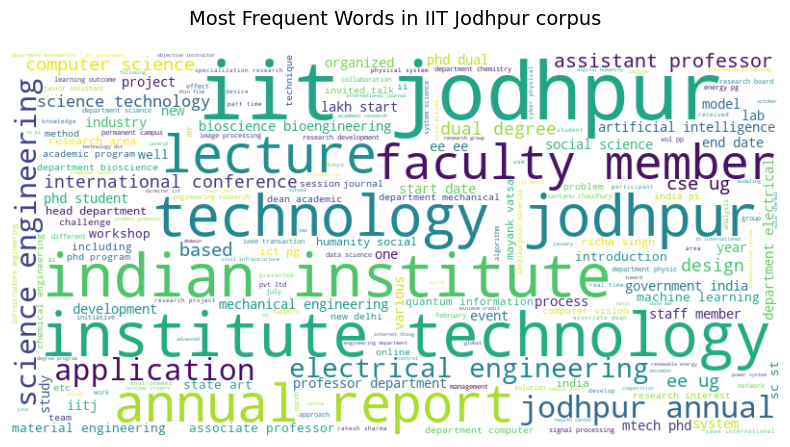

In [ ]:
# Text normalization function that converts raw scraped docs into cleaned tokens.
def preprocess_text(raw_docs):
    cleaned_corpus = []  # List of cleaned token lists (one per document)
    all_tokens = []  # Flattened token stream for corpus-level statistics
    stop_words = set(stopwords.words('english'))  # Base English stopword set
    lemmatizer = WordNetLemmatizer()  # Normalize inflected words to lemmas

    # Add webpage boilerplate terms that are frequent but semantically weak.
    custom_stops = {
        'home','about','contact','login','copyright','reserved','links','pdf','download','click','https','com','www','org','net','edu','doi',
        'dr','prof','kumar','http','ac','ha','wa','using','also'
    }  # Domain-specific noise terms from webpages/navigation
    stop_words.update(custom_stops)  # Merge custom stopwords with NLTK stopwords

    # Process each raw document independently so per-document structure is preserved.
    for doc in raw_docs:
        clean_text = doc.lower()  # Normalize to lowercase before cleanup
        clean_text = clean_text.replace('b.tech', 'btech').replace('m.tech', 'mtech')  # Keep common degree terms as single tokens
        clean_text = clean_text.replace('ph.d.', 'phd').replace('ph.d', 'phd')  # Normalize PhD spelling variants
        clean_text = clean_text.replace('u.g.', 'ug').replace('p.g.', 'pg')  # Normalize UG/PG forms
        clean_text = clean_text.replace('ofthe', 'of the')  # Fix joined token artifact

        # Remove URL fragments and symbols before tokenization.
        clean_text = re.sub(r'https?://\S+|www\.\S+', ' ', clean_text)  # Remove URL strings
        clean_text = re.sub(r'[^a-zA-Z\s]', ' ', clean_text)  # Keep only letters and spaces

        # Tokenize then lemmatize to reduce lexical sparsity.
        tokens = nltk.word_tokenize(clean_text.lower())  # Tokenize normalized text
        tokens = [lemmatizer.lemmatize(t) for t in tokens]  # Lemmatize each token

        # Filter out stopwords and extreme-length artifacts.
        filtered_tokens = [w for w in tokens if w not in stop_words and len(w) > 1 and len(w) < 20]  # Remove stopwords/noise tokens

        # Keep both document-wise and corpus-wise token views for later tasks.
        if filtered_tokens:
            cleaned_corpus.append(filtered_tokens)  # Store per-document cleaned tokens
            all_tokens.extend(filtered_tokens)  # Add into global token list

    return cleaned_corpus, all_tokens


# Load raw corpus collected in the previous scraping step.
with open("iitj_raw_corpus.txt", "r", encoding="utf-8") as f:
    all_raw_docs_saved = [line.strip() for line in f.readlines()]  # Read corpus (one document per line)

# Run full preprocessing pipeline.
cleaned_corpus, all_tokens = preprocess_text(all_raw_docs_saved)  # Run full cleaning pipeline

# Persist cleaned corpus for reproducibility and later model training.
with open("iitj_clean_corpus.txt", "w", encoding="utf-8") as f:
    for doc in cleaned_corpus:
        f.write(" ".join(doc) + "\n")  # Save cleaned tokenized docs back to disk

# Assignment statistics required for report tables.
print("--- DATASET STATISTICS ---")
print(f"Total Documents (Webpages/PDFs): {len(cleaned_corpus)}")
print(f"Total Tokens: {len(all_tokens)}")
print(f"Vocabulary Size: {len(set(all_tokens))}")

# Word cloud gives quick qualitative check of dominant topics.
text_for_cloud = " ".join(all_tokens)  # Build one text blob for word-cloud fitting
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(text_for_cloud)  # Render frequent-token cloud

# Plot and display cloud inline in notebook.
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Frequent Words in IIT Jodhpur corpus", fontsize=14, pad=20)
plt.show()

In [ ]:
# Frequency summary from cleaned tokens for report-ready top terms.
word_counts = Counter(all_tokens)  # Count token frequencies across the whole cleaned corpus
print("\nTop 10 Most Common Words:")  # Header for compact result display
for word, count in word_counts.most_common(10):
    # Each printed pair supports the Top-10 table used in final write-up.
    print(f"{word}: {count}")  # Print token with its absolute frequency


Top 10 Most Common Words:
student: 7168
jodhpur: 5505
research: 4695
technology: 4603
institute: 4470
iit: 4357
engineering: 4296
department: 4145
system: 3903
science: 3604


# Task 2: Model Training (CBOW and Skip-gram)
This task prepares vocabulary and training pairs, then trains two Word2Vec variants using negative sampling. Controlled settings are used so model behavior can be compared fairly across the same corpus.

In [ ]:
# Reload dependencies used in from-scratch training cells.
import numpy as np  # Vector/matrix operations for from-scratch Word2Vec
import random  # Reproducible shuffling/sampling
from collections import Counter  # Token frequency counting

# Build model vocabulary from cleaned corpus file.
print("Building Vocabulary...")
cleaned_corpus_saved = []  # Stores tokenized documents loaded from cleaned corpus
with open("iitj_clean_corpus.txt", "r", encoding="utf-8") as f:
    for line in f:
        cleaned_corpus_saved.append(line.strip().split())  # Convert each line back to token list

# Flatten tokens for frequency-based filtering.
all_words = [word for doc in cleaned_corpus_saved for word in doc]  # Flatten documents to one token stream
word_counts = Counter(all_words)  # Count token frequencies

# Minimum frequency threshold controls vocabulary noise and size.
MIN_COUNT = 5  # Minimum frequency threshold for vocabulary inclusion
vocab_words = [w for w, count in word_counts.items() if count >= MIN_COUNT]  # Remove rare words

# Preserve short academic abbreviations that are semantically important.
vocab_words = [w for w in vocab_words if len(w) > 2 or w in {'ug', 'pg', 'sc', 'st'}]  # Keep short but meaningful abbreviations

vocab_size = len(vocab_words)
word2idx = {w: idx for idx, w in enumerate(vocab_words)}  # Token -> index mapping
idx2word = {idx: w for w, idx in word2idx.items()}  # Index -> token mapping
print(f"Final Vocabulary Size: {vocab_size}")

# Build SGNS negative-sampling distribution p(w)^0.75.
print("Calculating Noise Distribution for Negative Sampling...")
total_words = sum(word_counts[w] for w in vocab_words)  # Total token count over retained vocabulary
unigram_dist = np.array([word_counts[w] / total_words for w in vocab_words], dtype=np.float64)  # Empirical unigram probabilities
noise_dist = unigram_dist ** 0.75  # SGNS smoothing
noise_dist = noise_dist / noise_dist.sum()  # Normalize to a valid probability distribution

# Convert corpus to integer-index representation for fast training.
corpus_indices = [[word2idx[w] for w in doc if w in word2idx] for doc in cleaned_corpus_saved]  # Convert corpus words to indices

Building Vocabulary...
Final Vocabulary Size: 10069
Calculating Noise Distribution for Negative Sampling...


In [ ]:
# Window size defines how many tokens on each side are treated as context.
WINDOW_SIZE = 5  # Context radius on each side for CBOW/Skip-gram supervision


def generate_skipgram_data(corpus, window_size):
    # Skip-gram objective: predict each context word from center word.
    data = []  # Stores (target, context) pairs
    for doc in corpus:  # Process each document independently
        for i, target in enumerate(doc):  # Select center word
            start = max(0, i - window_size)  # Left window boundary
            end = min(len(doc), i + window_size + 1)  # Right window boundary (exclusive)
            for j in range(start, end):
                if i != j:
                    data.append((target, doc[j]))  # Pair center with each surrounding context word
    return data


def generate_cbow_data(corpus, window_size):
    # CBOW objective: predict center word from surrounding context bag.
    data = []  # Stores (context_list, target) pairs
    for doc in corpus:  # Process each document independently
        for i in range(window_size, len(doc) - window_size):  # Keep only positions with full context
            context = doc[i - window_size : i] + doc[i + 1 : i + window_size + 1]  # Concatenate left and right contexts
            target = doc[i]  # Center word to predict
            data.append((context, target))
    return data


# Generate training supervision for both model variants.
print("Generating training pairs...")
sg_data = generate_skipgram_data(corpus_indices, WINDOW_SIZE)  # Build Skip-gram pairs
cbow_data = generate_cbow_data(corpus_indices, WINDOW_SIZE)  # Build CBOW pairs

# Report sample counts for documentation and sanity check.
print(f"Skip-gram pairs: {len(sg_data)}")
print(f"CBOW pairs: {len(cbow_data)}")

Generating training pairs...
Skip-gram pairs: 5828080
CBOW pairs: 582311


In [ ]:
# Numerically stable sigmoid used by SGNS loss terms.
def _sigmoid(x):
    x = np.clip(x, -15, 15)  # Prevent overflow in exp for large magnitudes
    return 1.0 / (1.0 + np.exp(-x))


# Base class storing shared components for SGNS-based CBOW and Skip-gram.
class Word2VecNegSampling:
    def __init__(self, vocab_size, embed_size, noise_dist, k_neg_samples=5, seed=42):
        self.vocab_size = vocab_size
        self.embed_size = embed_size
        self.k_neg_samples = k_neg_samples
        self.noise_dist = noise_dist.astype(np.float64)
        self.rng = np.random.default_rng(seed)  # Independent RNG for reproducible sampling

        init_range = 0.5 / embed_size  # Small init range for stable early gradients
        self.center_embeddings = self.rng.uniform(-init_range, init_range, (vocab_size, embed_size)).astype(np.float32)
        self.context_embeddings = self.rng.uniform(-init_range, init_range, (vocab_size, embed_size)).astype(np.float32)

    def sample_negatives(self, batch_size):
        # Shape: [batch_size, k_neg_samples].
        return self.rng.choice(
            self.vocab_size,
            size=(batch_size, self.k_neg_samples),
            p=self.noise_dist,
            replace=True
        )  # Draw negatives from smoothed unigram distribution


# Skip-gram with negative sampling implementation.
class SkipGram(Word2VecNegSampling):
    def train_batch(self, target_words, context_words, lr):
        batch_size = target_words.shape[0]
        eps = 1e-9  # Numerical safety for log()

        target_embs = self.center_embeddings[target_words]  # Center-word vectors
        context_embs = self.context_embeddings[context_words]  # Positive context vectors

        # Positive objective term: log sigma(v_t . u_c)
        pos_score = np.sum(target_embs * context_embs, axis=1)  # Dot product for positive pairs
        pos_sig = _sigmoid(pos_score)
        pos_loss = -np.log(pos_sig + eps)

        # Negative objective term: sum log sigma(-v_t . u_n)
        neg_words = self.sample_negatives(batch_size)
        neg_embs = self.context_embeddings[neg_words]  # Negative context vectors
        neg_score = np.einsum("bke,be->bk", neg_embs, target_embs)  # Dot products with negatives
        neg_sig = _sigmoid(-neg_score)
        neg_loss = -np.sum(np.log(neg_sig + eps), axis=1)

        loss = np.mean(pos_loss + neg_loss)

        # Derivatives of SGNS objective wrt logits.
        g_pos = (pos_sig - 1.0)  # d/dx[-log(sigmoid(x))]
        g_neg = _sigmoid(neg_score)  # d/dx[-log(sigmoid(-x))]

        # Build embedding gradients for center, positive context, and negative context vectors.
        grad_target = (g_pos[:, None] * context_embs) + np.sum(g_neg[:, :, None] * neg_embs, axis=1)
        grad_context = g_pos[:, None] * target_embs
        grad_neg = g_neg[:, :, None] * target_embs[:, None, :]

        scale = lr
        np.add.at(self.center_embeddings, target_words, -scale * grad_target)  # Sparse-safe center updates
        np.add.at(self.context_embeddings, context_words, -scale * grad_context)  # Positive context updates
        np.add.at(self.context_embeddings, neg_words.reshape(-1), -scale * grad_neg.reshape(-1, self.embed_size))  # Negative context updates

        return float(loss)


# CBOW with negative sampling implementation.
class CBOW(Word2VecNegSampling):
    def train_batch(self, context_words, target_words, lr):
        batch_size = target_words.shape[0]
        context_len = context_words.shape[1]
        eps = 1e-9

        # Average context vectors to form predictor representation.
        context_embs = self.context_embeddings[context_words]  # Context-word vectors
        context_mean = np.mean(context_embs, axis=1)  # Mean context representation
        target_embs = self.center_embeddings[target_words]  # Target vectors

        # Positive objective term.
        pos_score = np.sum(context_mean * target_embs, axis=1)
        pos_sig = _sigmoid(pos_score)
        pos_loss = -np.log(pos_sig + eps)

        # Negative objective term.
        neg_words = self.sample_negatives(batch_size)
        neg_embs = self.center_embeddings[neg_words]
        neg_score = np.einsum("bke,be->bk", neg_embs, context_mean)
        neg_sig = _sigmoid(-neg_score)
        neg_loss = -np.sum(np.log(neg_sig + eps), axis=1)

        loss = np.mean(pos_loss + neg_loss)

        # Derivatives wrt positive and negative logits.
        g_pos = (pos_sig - 1.0)
        g_neg = _sigmoid(neg_score)

        # Backprop from context mean to each context token embedding.
        grad_target = g_pos[:, None] * context_mean
        grad_context_mean = (g_pos[:, None] * target_embs) + np.sum(g_neg[:, :, None] * neg_embs, axis=1)
        grad_context_each = np.repeat((grad_context_mean / context_len)[:, None, :], context_len, axis=1)  # Split mean-gradient back to each context token
        grad_neg = g_neg[:, :, None] * context_mean[:, None, :]

        scale = lr
        np.add.at(self.center_embeddings, target_words, -scale * grad_target)  # Positive target updates
        np.add.at(self.center_embeddings, neg_words.reshape(-1), -scale * grad_neg.reshape(-1, self.embed_size))  # Negative target updates
        np.add.at(self.context_embeddings, context_words.reshape(-1), -scale * grad_context_each.reshape(-1, self.embed_size))  # Context updates

        return float(loss)

In [ ]:
# Shared training hyperparameters for fair CBOW vs Skip-gram comparison.
EMBEDDING_DIM = 300
BATCH_SIZE = 128
EPOCHS = 10
LEARNING_RATE = 0.025
K_NEG_SAMPLES = 5

np.random.seed(42)  # Reproducible shuffling and numeric behavior
random.seed(42)  # Reproducible Python-level randomness


def train_model(model, data, model_name, is_cbow=False):
    print(f"\n--- Training {model_name} ---")
    n = len(data)

    for epoch in range(EPOCHS):
        # Shuffle each epoch so gradient steps do not depend on fixed order.
        indices = np.random.permutation(n)  # Shuffle order every epoch
        total_loss = 0.0
        steps = 0

        # Light linear decay stabilizes later updates.
        lr_epoch = LEARNING_RATE * (1.0 - 0.5 * (epoch / max(EPOCHS - 1, 1)))  # Linear LR decay across epochs

        for start in range(0, n, BATCH_SIZE):
            batch_idx = indices[start : start + BATCH_SIZE]
            batch = [data[i] for i in batch_idx]

            if is_cbow:
                contexts = np.array([x[0] for x in batch], dtype=np.int64)
                targets = np.array([x[1] for x in batch], dtype=np.int64)
                loss = model.train_batch(contexts, targets, lr_epoch)  # CBOW update
            else:
                inputs = np.array([x[0] for x in batch], dtype=np.int64)
                targets = np.array([x[1] for x in batch], dtype=np.int64)
                loss = model.train_batch(inputs, targets, lr_epoch)  # Skip-gram update

            total_loss += loss
            steps += 1

        avg_loss = total_loss / max(steps, 1)
        print(f"Epoch {epoch+1}/{EPOCHS} | LR: {lr_epoch:.5f} | Avg Loss: {avg_loss:.4f}")

    print(f"{model_name} training complete!")
    return model


# Initialize both models with identical dimensions and sampling settings.
cbow_model = CBOW(vocab_size, EMBEDDING_DIM, noise_dist, K_NEG_SAMPLES, seed=42)  # Initialize CBOW model
skipgram_model = SkipGram(vocab_size, EMBEDDING_DIM, noise_dist, K_NEG_SAMPLES, seed=42)  # Initialize Skip-gram model

# Train each model on its corresponding supervision format.
cbow_model = train_model(cbow_model, cbow_data, "CBOW", is_cbow=True)  # Train CBOW on CBOW pairs
skipgram_model = train_model(skipgram_model, sg_data, "Skip-gram", is_cbow=False)  # Train Skip-gram on SG pairs


--- Training CBOW ---
Epoch 1/10 | LR: 0.02500 | Avg Loss: 3.4791
Epoch 2/10 | LR: 0.02361 | Avg Loss: 2.4600
Epoch 3/10 | LR: 0.02222 | Avg Loss: 2.2014
Epoch 4/10 | LR: 0.02083 | Avg Loss: 2.0554
Epoch 5/10 | LR: 0.01944 | Avg Loss: 1.9454
Epoch 6/10 | LR: 0.01806 | Avg Loss: 1.8563
Epoch 7/10 | LR: 0.01667 | Avg Loss: 1.7811
Epoch 8/10 | LR: 0.01528 | Avg Loss: 1.7180
Epoch 9/10 | LR: 0.01389 | Avg Loss: 1.6644
Epoch 10/10 | LR: 0.01250 | Avg Loss: 1.6206
CBOW training complete!

--- Training Skip-gram ---
Epoch 1/10 | LR: 0.02500 | Avg Loss: 2.4500
Epoch 2/10 | LR: 0.02361 | Avg Loss: 2.0303
Epoch 3/10 | LR: 0.02222 | Avg Loss: 1.9045
Epoch 4/10 | LR: 0.02083 | Avg Loss: 1.8205
Epoch 5/10 | LR: 0.01944 | Avg Loss: 1.7579
Epoch 6/10 | LR: 0.01806 | Avg Loss: 1.7080
Epoch 7/10 | LR: 0.01667 | Avg Loss: 1.6683
Epoch 8/10 | LR: 0.01528 | Avg Loss: 1.6347
Epoch 9/10 | LR: 0.01389 | Avg Loss: 1.6061
Epoch 10/10 | LR: 0.01250 | Avg Loss: 1.5808
Skip-gram training complete!


In [ ]:
# Quick qualitative inspection of one learned vector from each model.
word = 'engineering'  # Domain word for quick embedding sanity check
if word in word2idx:
    idx = word2idx[word]  # Convert token to embedding row index
    cbow_embedding = cbow_model.center_embeddings[idx]  # CBOW vector for the word
    skipgram_embedding = skipgram_model.center_embeddings[idx]  # Skip-gram vector for the word
    # Printing full vectors helps verify non-zero training and representation differences.
    print(f"\nCBOW embedding for '{word}':\n{cbow_embedding}\n")
    print(f"Skip-gram embedding for '{word}':\n{skipgram_embedding}\n")
else:
    print(f"'{word}' is not present in the final vocabulary.")  # Handle filtered/OOV token


CBOW embedding for 'engineering':
[-4.89912182e-01 -4.83640790e-01 -2.00755939e-01 -4.96377610e-02
  1.66067258e-01 -3.05770844e-01 -4.00278360e-01 -8.81233275e-01
  1.04629263e-01  6.50328219e-01  1.95206448e-01  4.59657699e-01
  3.07023168e-01  2.95351520e-02  7.63375163e-01 -4.65889066e-01
  3.06736410e-01  4.76583317e-02  1.13599397e-01 -1.12385064e-01
 -7.59220660e-01 -8.67866933e-01  4.71704513e-01 -4.00153339e-01
  7.33010888e-01 -9.98208761e-01 -5.18555045e-01 -1.07670665e+00
 -9.86067504e-02  2.43555784e-01 -4.17728603e-01 -4.35153544e-01
 -1.00229573e+00  3.32097709e-01 -9.62104797e-02  2.43208483e-01
  2.75161535e-01  7.52048135e-01  1.00850284e-01  5.28730512e-01
 -3.76848102e-01 -1.44434437e-01  8.47353101e-01  1.36890322e-01
 -3.56571525e-01  1.85041785e-01  3.52602392e-01 -8.48278403e-01
  1.35903823e+00 -1.68805853e-01 -8.58376145e-01  2.06859608e-04
  1.12567067e+00  7.30041880e-03  4.05438751e-01 -9.28456366e-01
  3.31794709e-01 -1.12502612e-01  4.66220975e-01 -8.310

# Task 3: Semantic Analysis
This task evaluates embedding quality using nearest-neighbor lookup and analogy reasoning with cosine similarity. The analysis checks whether IITJ domain semantics are captured in both CBOW and Skip-gram spaces.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity  # Cosine similarity for semantic closeness in embedding space
import numpy as np  # Vector arithmetic for analogy composition

# Use center embeddings for semantic probing and analogy evaluation.
cbow_vectors = cbow_model.center_embeddings  # CBOW embedding matrix [V, D]
skipgram_vectors = skipgram_model.center_embeddings  # Skip-gram embedding matrix [V, D]


def get_nearest_neighbors(target_word, vectors, word2idx, idx2word, top_n=5):
    # Return OOV marker instead of throwing error when term is unavailable.
    if target_word not in word2idx:
        return [("[OOV - Out of Vocab]", 0.0)]  # Stable output format when probe word is missing

    target_idx = word2idx[target_word]
    target_vec = vectors[target_idx].reshape(1, -1)  # 2D shape for sklearn API

    similarities = cosine_similarity(target_vec, vectors)[0]  # Similarity to every token
    top_indices = similarities.argsort()[-(top_n + 1):-1][::-1]  # Best neighbors except self

    return [(idx2word[i], similarities[i]) for i in top_indices]


def solve_analogy(word_a, word_b, word_c, vectors, word2idx, idx2word):
    # Validate all three input terms before vector arithmetic.
    for w in [word_a, word_b, word_c]:
        if w not in word2idx:
            return f"[SKIPPED: '{w}' missing from vocab]"  # Explicit reason for skipped analogy

    vec_a = vectors[word2idx[word_a]]
    vec_b = vectors[word2idx[word_b]]
    vec_c = vectors[word2idx[word_c]]

    # Core analogy equation: B - A + C.
    vec_d = vec_b - vec_a + vec_c  # Analogy formula: A:B::C:D
    vec_d = vec_d.reshape(1, -1)

    similarities = cosine_similarity(vec_d, vectors)[0]
    sorted_indices = similarities.argsort()[::-1]  # Highest score first

    # Exclude source words to avoid trivial matches.
    exclude = {word2idx[word_a], word2idx[word_b], word2idx[word_c]}  # Avoid returning source words
    for idx in sorted_indices:
        if idx not in exclude:
            return f"{idx2word[idx]} (Score: {similarities[idx]:.4f})"

    return "No match found."


def run_task_3_analysis(model_name, vectors):
    # Structured printing block for easy copy into report sections.
    print(f"\n{'='*50}")
    print(f" TASK 3: SEMANTIC ANALYSIS - {model_name.upper()} ")
    print(f"{'='*50}")

    print("\n1. TOP 5 NEAREST NEIGHBORS")
    target_words = ['research', 'student', 'phd', 'exam']  # Assignment probe words

    for word in target_words:
        print(f"\nTarget: {word.upper()}")
        neighbors = get_nearest_neighbors(word, vectors, word2idx, idx2word, top_n=5)
        for neighbor, score in neighbors:
            print(f"  -> {neighbor} ({score:.4f})")

    print("\n2. ANALOGY EXPERIMENTS")
    analogies = [
        ('ug', 'btech', 'pg', "UG : BTech :: PG : ?"),
        ('undergraduate', 'btech', 'postgraduate', "Undergraduate : BTech :: Postgraduate : ?"),
        ('student', 'course', 'researcher', "Student : Course :: Researcher : ?"),
        ('theory', 'exam', 'practical', "Theory : Exam :: Practical : ?"),
        ('phd', 'thesis', 'mtech', "PhD : Thesis :: MTech : ?"),
        ('research', 'publication', 'innovation', "Research : Publication :: Innovation : ?"),
        ('department', 'faculty', 'course', "Department : Faculty :: Course : ?"),
        ('admission', 'program', 'curriculum', "Admission : Program :: Curriculum : ?"),
        ('semester', 'course', 'program', "Semester : Course :: Program : ?"),
        ('institute', 'department', 'school', "Institute : Department :: School : ?")
    ]

    for a, b, c, description in analogies:
        result = solve_analogy(a, b, c, vectors, word2idx, idx2word)
        print(f"  {description} \n    -> Result: {result}\n")


# Run full semantic analysis for both trained spaces.
run_task_3_analysis("CBOW", cbow_vectors)  # Analyze CBOW semantic structure
run_task_3_analysis("Skip-gram", skipgram_vectors)  # Analyze Skip-gram semantic structure


 TASK 3: SEMANTIC ANALYSIS - CBOW 

1. TOP 5 NEAREST NEIGHBORS

Target: RESEARCH
  -> researcher (0.5111)
  -> award (0.4067)
  -> collaboration (0.3954)
  -> work (0.3918)
  -> career (0.3833)

Target: STUDENT
  -> program (0.5307)
  -> various (0.4100)
  -> career (0.3929)
  -> team (0.3835)
  -> member (0.3610)

Target: PHD
  -> mtech (0.7764)
  -> mmt (0.7710)
  -> msc (0.7691)
  -> amd (0.7313)
  -> jpd (0.7310)

Target: EXAM
  -> cancel (0.9594)
  -> asked (0.9590)
  -> decide (0.9583)
  -> clearing (0.9507)
  -> spend (0.9488)

2. ANALOGY EXPERIMENTS
  UG : BTech :: PG : ? 
    -> Result: diploma (Score: 0.7127)

  Undergraduate : BTech :: Postgraduate : ? 
    -> Result: bachelor (Score: 0.8275)

  Student : Course :: Researcher : ? 
    -> Result: laboratory (Score: 0.4532)

  Theory : Exam :: Practical : ? 
    -> Result: availing (Score: 0.7971)

  PhD : Thesis :: MTech : ? 
    -> Result: candidate (Score: 0.8204)

  Research : Publication :: Innovation : ? 
    -> Result:

# Task 4: Visualization with t-SNE
This section projects selected embedding neighborhoods into 2D using t-SNE to inspect semantic grouping around academic seed words.

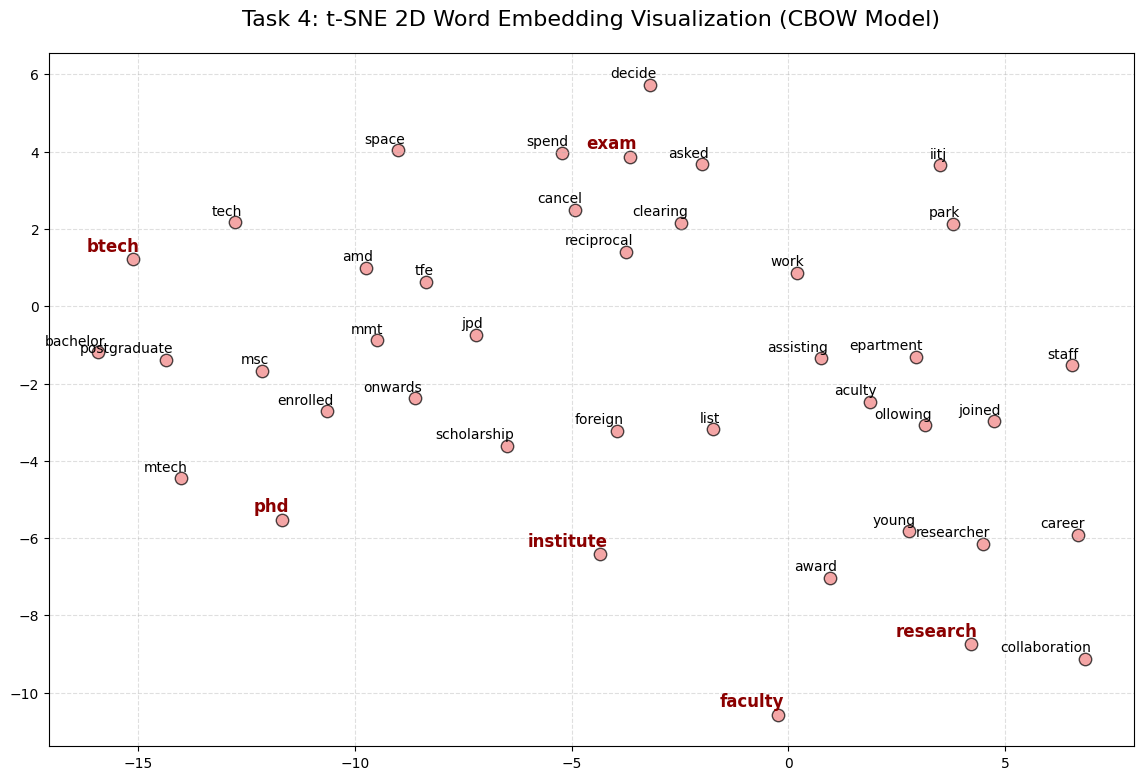

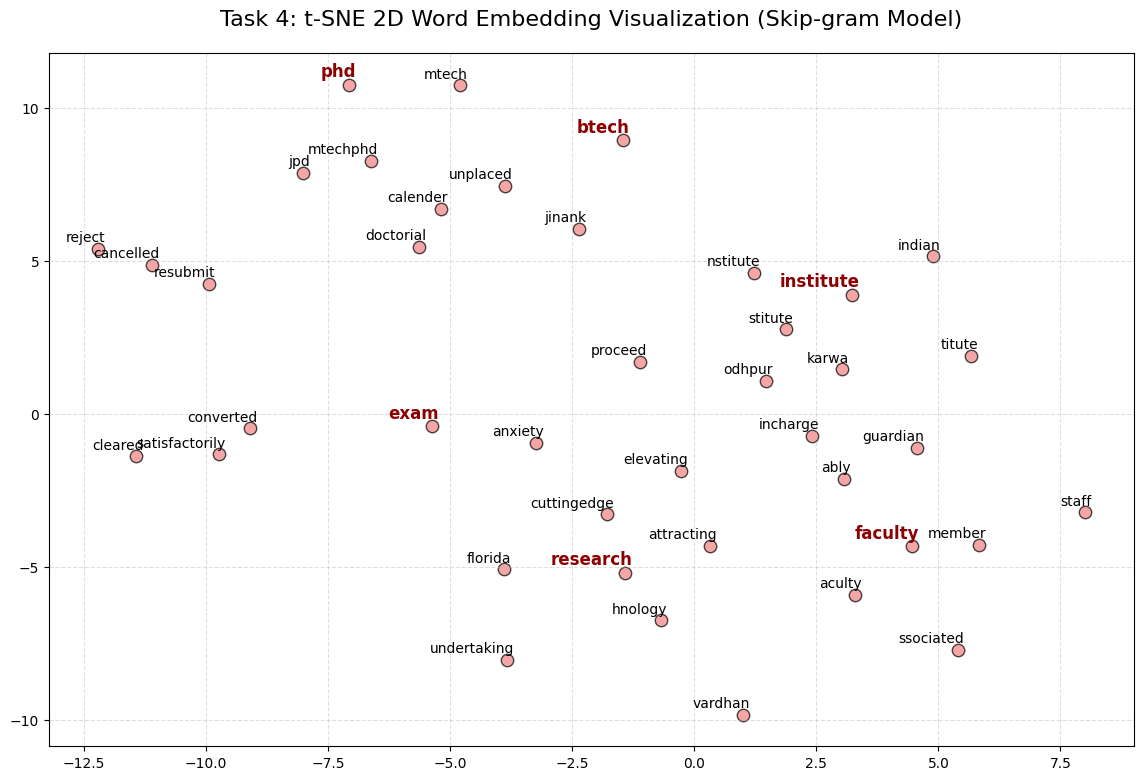

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt


# t-SNE-based local neighborhood visualization around selected seed words.
def visualize_clusters(vectors, model_name):
    seed_words = ['research', 'btech', 'phd', 'exam', 'faculty', 'institute']  # Words around which local neighborhoods are visualized
    words_to_plot = set()

    # Build candidate set = seeds + nearest neighbors.
    for word in seed_words:
        if word in word2idx:
            words_to_plot.add(word)
            neighbors = get_nearest_neighbors(word, vectors, word2idx, idx2word, top_n=6)  # Add nearest neighbors of each seed
            for n_word, _ in neighbors:
                if n_word != "[OOV - Out of Vocab]":
                    words_to_plot.add(n_word)

    words_to_plot = list(words_to_plot)

    # Skip plotting if sample is too small for meaningful 2D projection.
    if len(words_to_plot) < 5:
        print(f"Not enough vocabulary to visualize for {model_name}.")
        return

    plot_vectors = np.array([vectors[word2idx[w]] for w in words_to_plot])  # Extract vectors in plotting order

    # Perplexity is capped for stability when point count is small.
    tsne = TSNE(n_components=2, perplexity=min(12, len(words_to_plot)-1), random_state=42, init='pca')  # Low perplexity for small sample size
    vectors_2d = tsne.fit_transform(plot_vectors)

    plt.figure(figsize=(14, 9))
    plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], c='lightcoral', edgecolors='k', s=80, alpha=0.7)

    # Label seeds prominently and neighbors with standard style.
    for i, word in enumerate(words_to_plot):
        if word in seed_words:
            plt.annotate(word, xy=(vectors_2d[i, 0], vectors_2d[i, 1]), xytext=(5, 3),
                         textcoords='offset points', ha='right', va='bottom',
                         color='darkred', weight='bold', fontsize=12)  # Highlight seed words
        else:
            plt.annotate(word, xy=(vectors_2d[i, 0], vectors_2d[i, 1]), xytext=(5, 3),
                         textcoords='offset points', ha='right', va='bottom',
                         color='black', fontsize=10)  # Regular labels for neighbors

    plt.title(f"Task 4: t-SNE 2D Word Embedding Visualization ({model_name})", fontsize=16, pad=20)
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.show()


# Render t-SNE for both trained models.
visualize_clusters(cbow_vectors, "CBOW Model")  # t-SNE projection for CBOW
visualize_clusters(skipgram_vectors, "Skip-gram Model")  # t-SNE projection for Skip-gram

# Task 4: Visualization with PCA
This section repeats the 2D projection with PCA to compare global linear structure against the non-linear t-SNE view.

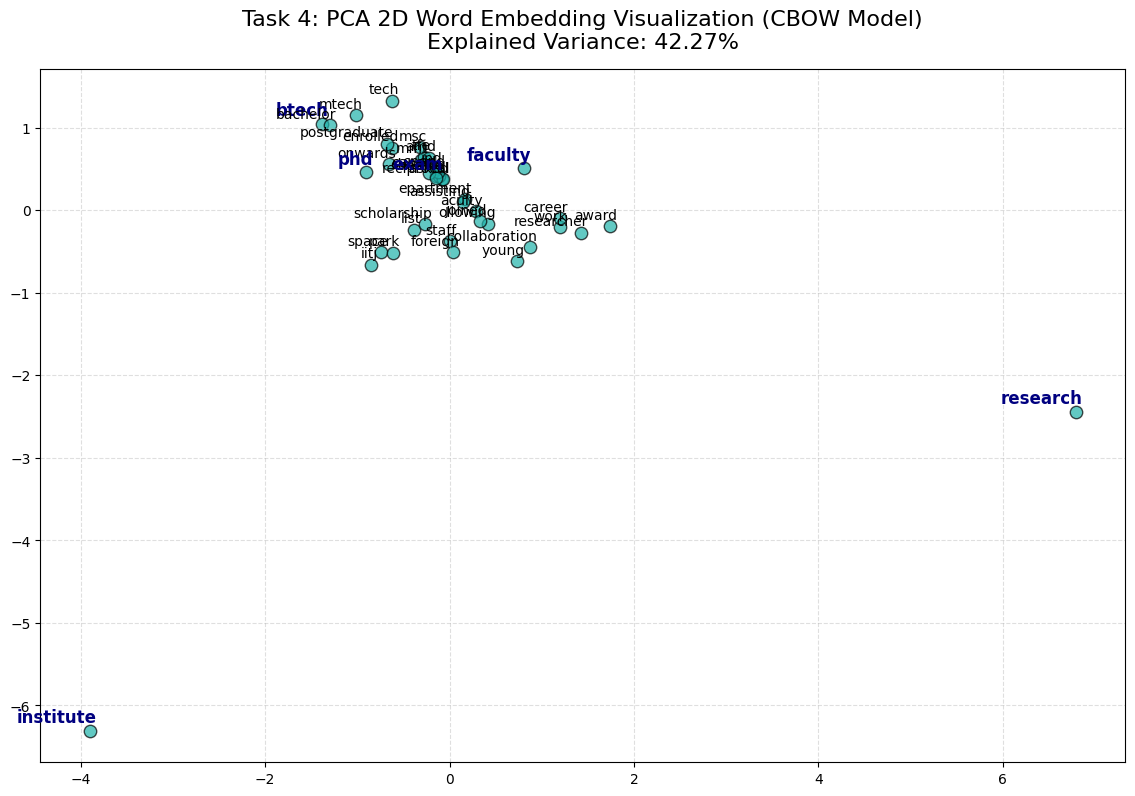

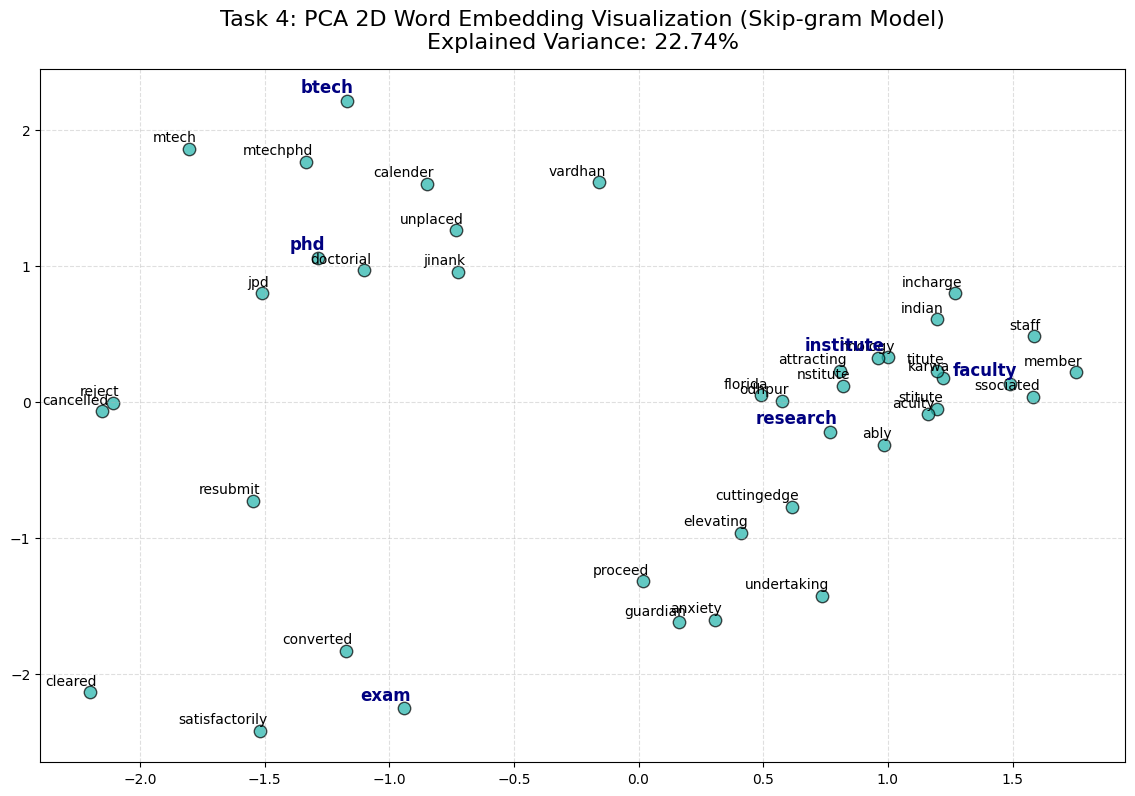

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np


# PCA-based global-structure projection using the same seed neighborhoods as t-SNE.
def visualize_clusters_pca(vectors, model_name):
    seed_words = ['research', 'btech', 'phd', 'exam', 'faculty', 'institute']  # Same seeds as t-SNE for fair comparison
    words_to_plot = set()

    # Keep identical selection logic for apples-to-apples comparison with t-SNE.
    for word in seed_words:
        if word in word2idx:
            words_to_plot.add(word)
            neighbors = get_nearest_neighbors(word, vectors, word2idx, idx2word, top_n=6)
            for n_word, _ in neighbors:
                if n_word != "[OOV - Out of Vocab]":
                    words_to_plot.add(n_word)

    words_to_plot = list(words_to_plot)

    # Guard against too few points for meaningful scatter structure.
    if len(words_to_plot) < 5:
        print(f"Not enough vocabulary to visualize for {model_name}.")
        return

    plot_vectors = np.array([vectors[word2idx[w]] for w in words_to_plot])  # Collect selected embeddings

    # PCA is deterministic and reports explained variance directly.
    pca = PCA(n_components=2, random_state=42)  # Linear 2D projection
    vectors_2d = pca.fit_transform(plot_vectors)

    plt.figure(figsize=(14, 9))
    plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], c='lightseagreen', edgecolors='k', s=80, alpha=0.7)

    # Styling mirrors t-SNE cell: seeds bold, neighbors normal.
    for i, word in enumerate(words_to_plot):
        if word in seed_words:
            plt.annotate(word, xy=(vectors_2d[i, 0], vectors_2d[i, 1]), xytext=(5, 3),
                         textcoords='offset points', ha='right', va='bottom',
                         color='navy', weight='bold', fontsize=12)  # Emphasize seed words
        else:
            plt.annotate(word, xy=(vectors_2d[i, 0], vectors_2d[i, 1]), xytext=(5, 3),
                         textcoords='offset points', ha='right', va='bottom',
                         color='black', fontsize=10)  # Standard labels

    explained_variance = sum(pca.explained_variance_ratio_) * 100  # Variance captured by first two PCs
    plt.title(
        f"Task 4: PCA 2D Word Embedding Visualization ({model_name})\nExplained Variance: {explained_variance:.2f}%",
        fontsize=16,
        pad=15
    )
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.show()


# Render PCA for both trained models.
visualize_clusters_pca(cbow_vectors, "CBOW Model")  # PCA projection for CBOW
visualize_clusters_pca(skipgram_vectors, "Skip-gram Model")  # PCA projection for Skip-gram